## 7CS082/UZ3 Final Assessment: Next-Day Ethereum Price Prediction Using Bidirectional LSTM Networks

**Student:** Santiago Cruz Lopez (2584023)  
**Module:** Deep Machine Learning (7CS082/UZ3)  
**Professor:** Nate Martins  
**Date:** March 9, 2026  

#### Abstract

The objective of this research report is to predict the closing price of Ethereum (ETH) for the following day using deep machine learning methods. Specifically, it utilizes a bidirectional LSTM (Long Term Short Term Memory) neural network with Layer Normalization, implemented in TensorFlow. The model is built using 14 constructed time series attributes derived from historical OHLCV (Open, High, Low, Close, and Volume) data, spanning from August 7, 2015, to March 1, 2026 [1](https://www.tensorflow.org/tutorials/structured_data/time_series).

The technique uses chronological data segmentation, objective scaling with logarithmic conversion, and a 90-day lookback window to capture temporal dependencies and prevent information leakage. The model employs Huber loss to improve robustness to outliers in fluctuating cryptocurrency markets and includes gradient trimming and adaptive learning rate scheduling [2](https://otexts.com/fpp3/).

Conventional time series diagnostics (such as seasonality analysis, stationarity tests, and support and resistance identification) complement the deep learning perspective by providing 95% confidence intervals for risk-aware trading decisions, as well as point forecasts. Comprehensive evaluation metrics (MAE, MAPE, RMSE, R²) are calculated in the testing, validation, and training phases, enabling deployment and reproducibility with full model persistence [3](https://www.investopedia.com/terms/v/volatility.asp).

#### Table Of Contents
1. Problem Statement  
2. Dataset Description  
3. Methodology: Preprocessing, EDA, and Feature Engineering  
4. Support and Resistance Analysis  
5. TensorFlow LSTM Modeling and Train/Validation/Test Strategy  
6. Results and Interpretation  
7. Conclusion and References

---

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from statsmodels.tsa.stattools import adfuller

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef, cohen_kappa_score,
    log_loss, brier_score_loss, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

In [3]:
# Load the dataset
csv_path = Path("Ethereum_historical_data_coinmarketcap.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Dataset not found: {csv_path.resolve()}")

raw_df = pd.read_csv(csv_path, sep=";")
print("Raw shape:", raw_df.shape)
print("Raw columns:", list(raw_df.columns))

df = raw_df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")

invalid_ts = df["timestamp"].isna().sum()
dup_count_before = df.duplicated().sum()

df = df.dropna(subset=["timestamp"]).drop_duplicates().sort_values("timestamp").set_index("timestamp")

drop_cols = ["timeOpen", "timeClose", "timeHigh", "timeLow", "name"]
df = df.drop(columns=drop_cols, errors="ignore")

print("\nInvalid timestamps removed:", invalid_ts)
print("Duplicate rows removed:", dup_count_before)
print("Final shape:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())
print("\nData types:\n", df.dtypes)

Raw shape: (3860, 13)
Raw columns: ['timeOpen', 'timeClose', 'timeHigh', 'timeLow', 'name', 'open', 'high', 'low', 'close', 'volume', 'marketCap', 'circulatingSupply', 'timestamp']

Invalid timestamps removed: 0
Duplicate rows removed: 0
Final shape: (3860, 7)

Missing values per column:
 open                 0
high                 0
low                  0
close                0
volume               0
marketCap            0
circulatingSupply    0
dtype: int64

Data types:
 open                 float64
high                 float64
low                  float64
close                float64
volume               float64
marketCap            float64
circulatingSupply    float64
dtype: object


---

### 1. Problem Statement

#### 1.2 Objectives
The objective of this research is to create a robust LSTM model that, using TensorFlow, accurately forecasts the closing price of Ethereum for the following day. The main objectives are:

- Predict the closing price of Ethereum for the day following the trade with minimal predictive error (RMSE, MAE, MAPE).
- Determine essential resistance and support levels for establishing trading strategies.
- Establish the ideal lookback window for sequential model inputs.
- Understand the time series properties (seasonality, volatility, trend) that generate price changes.

#### 1.2 Relevance and Motivation

- **Risk Management:** Traders can set take-profit and stop-loss levels based on expected price ranges.
- **Portfolio Optimization:** Investors can adjust their positions in anticipation of price fluctuations.
- **Market Understanding:** Financial analysts and academics gather information about the factors that influence the price of crypto assets.

---

---

### 2. Dataset Description

#### 2.1 Data Source and Collection
The dataset contains historical Ethereum price data sourced from CoinMarketCap, a leading cryptocurrency data aggregator [4](https://coinmarketcap.com/). The data spans multiple years and includes daily OHLCV (Open, High, Low, Close, Volume) metrics along with market capitalization and circulating supply.

#### 2.2 Data Structure and Features
The raw dataset includes:
- **timestamp:** Date and time of the observation (UTC)
- **open, high, low, close:** Daily price levels (USD)
- **volume:** Trading volume (USD)
- **marketCap:** Total market capitalization (USD)
- **circulatingSupply:** Number of ETH tokens in circulation
- **timeOpen, timeClose, timeHigh, timeLow:** Specific timestamps for price events (removed during preprocessing)
- **name:** Token identifier (removed during preprocessing)

#### 2.3 Preprocessing Steps
1. **Parse timestamps:** Convert string timestamps to pandas datetime objects with UTC timezone.
2. **Remove invalid records:** Drop rows with missing or unparseable timestamps.
3. **Deduplicate:** Remove duplicate rows to ensure data integrity.
4. **Sort and index:** Sort by timestamp and set as the index for time-series analysis.
5. **Drop redundant columns:** Remove timeOpen, timeClose, timeHigh, timeLow, and name columns.
6. **Validate data types:** Ensure numeric columns are properly typed for computation.

#### 2.4 Feature Engineering
To enhance predictive power, we create:
- **Lag features:** lag_close_1, lag_close_3, lag_close_7 (historical prices)
- **Return features:** ret_1d, ret_7d (percentage changes)
- **Volatility features:** volatility_7d (rolling standard deviation of returns)
- **Ratio features:** high_low_ratio, range_ratio, open_ratio (relative price metrics)
- **Target variable:** price_direction (binary: 1 if next-day close > today's close, else 0)

---

In [4]:
# Core features
df["lag_close_1"] = df["close"].shift(1)
df["lag_close_3"] = df["close"].shift(3)
df["lag_close_7"] = df["close"].shift(7)

# Return and volatility features
df["ret_1d"] = df["close"].pct_change(1)
df["ret_7d"] = df["close"].pct_change(7)
df["volatility_7d"] = df["ret_1d"].rolling(7).std()

# Ratio features
df["high_low_ratio"] = df["high"] / df["low"]
df["range_ratio"] = (df["high"] - df["low"]) / df["lag_close_1"]
df["open_ratio"] = df["open"] / df["lag_close_1"]

# Target: predict next-day direction
df["price_direction"] = (df["close"].shift(-1) > df["close"]).astype(int)

# Rolling trend feature for plotting/reporting
df["rolling_mean_30"] = df["close"].rolling(window=30).mean()

# Drop rows with NaN introduced by shifts/rolling
df_model = df.dropna().copy()

baseline_features = ["open", "high", "low", "volume", "lag_close_1"]
fe_features = baseline_features + [
    "lag_close_3", "lag_close_7",
    "ret_1d", "ret_7d", "volatility_7d",
    "high_low_ratio", "range_ratio", "open_ratio"
]

X_bl = df_model[baseline_features]
X_fe = df_model[fe_features]
y = df_model["price_direction"]

selected_df = df_model[baseline_features + ["close"]]

print("Model dataset shape:", df_model.shape)
print("\nClass balance:\n", y.value_counts(normalize=True).rename("proportion"))
print("\nSelected features preview:")
selected_df.head()

Model dataset shape: (3831, 18)

Class balance:
 price_direction
1    0.505873
0    0.494127
Name: proportion, dtype: float64

Selected features preview:


,open,high,low,volume,lag_close_1,close
timestamp,,,,,,
2015-09-05 23:59:59.999000+00:00,1.28056,1.34230,1.27119,448453.0,1.27441,1.33881
2015-09-06 23:59:59.999000+00:00,1.33801,1.37364,1.29425,491968.0,1.33881,1.29583
2015-09-07 23:59:59.999000+00:00,1.29590,1.30548,1.23785,489014.0,1.29583,1.24665
2015-09-08 23:59:59.999000+00:00,1.24665,1.28238,1.23061,427892.0,1.24665,1.24243
2015-09-09 23:59:59.999000+00:00,1.23935,1.26048,1.20184,366748.0,1.24243,1.20651


In [5]:
desc = X_fe.describe().T
desc["skew"] = X_fe.skew()
desc["kurtosis"] = X_fe.kurtosis()
print("Detailed descriptive statistics:\n")
display(desc[["mean", "std", "min", "25%", "50%", "75%", "max", "skew", "kurtosis"]])

# IQR outlier share
outlier_share = {}
for col in X_fe.columns:
    q1, q3 = X_fe[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_share[col] = ((X_fe[col] < lower) | (X_fe[col] > upper)).mean() * 100

outlier_df = pd.Series(outlier_share, name="outlier_%").sort_values(ascending=False)
print("\nOutlier share by feature (%):")
display(outlier_df.round(2).to_frame())

# ADF stationarity test on close
adf_stat, adf_pvalue, *_ = adfuller(df_model["close"])
print(f"ADF statistic: {adf_stat:.4f}")
print(f"ADF p-value: {adf_pvalue:.6f}")
if adf_pvalue > 0.05:
    print("Interpretation: likely non-stationary (trend/structural changes present).")
else:
    print("Interpretation: likely stationary series.")

Detailed descriptive statistics:



,mean,std,min,25%,50%,75%,max,skew,kurtosis
open,1.362974e+03,1.327307e+03,0.431589,1.806031e+02,9.447480e+02,2.424003e+03,4.831088e+03,0.652488,-0.843567
high,1.400060e+03,1.361811e+03,0.482988,1.850349e+02,9.829330e+02,2.499549e+03,4.953733e+03,0.650297,-0.849525
low,1.322311e+03,1.289225e+03,0.420897,1.752137e+02,8.929540e+02,2.338424e+03,4.718039e+03,0.654747,-0.837344
volume,1.202741e+10,1.256366e+10,102128.000000,1.757755e+09,8.918980e+09,1.772733e+10,9.773662e+10,1.645044,3.722059
lag_close_1,1.362838e+03,1.327137e+03,0.434829,1.806351e+02,9.442100e+02,2.423806e+03,4.831349e+03,0.652033,-0.845126
lag_close_3,1.361822e+03,1.327434e+03,0.434829,1.803900e+02,9.369760e+02,2.423806e+03,4.831349e+03,0.653285,-0.844497
lag_close_7,1.359790e+03,1.328022e+03,0.434829,1.798113e+02,8.953710e+02,2.423806e+03,4.831349e+03,0.655790,-0.843207
ret_1d,3.245789e-03,5.183938e-02,-0.423472,-2.026245e-02,3.859429e-04,2.366836e-02,3.554435e-01,0.524999,6.578346
ret_7d,2.437839e-02,1.588343e-01,-0.509975,-5.803999e-02,6.004634e-03,7.986309e-02,1.610340e+00,2.123901,12.362052
volatility_7d,4.330968e-02,2.735834e-02,0.003198,2.503187e-02,3.623679e-02,5.296845e-02,2.156775e-01,1.924535,5.504953



Outlier share by feature (%):


,outlier_%
open_ratio,23.41
ret_1d,7.88
high_low_ratio,6.63
ret_7d,6.29
range_ratio,6.24
volatility_7d,4.91
volume,3.68
open,0.00
high,0.00
low,0.00


ADF statistic: -2.1365
ADF p-value: 0.230103
Interpretation: likely non-stationary (trend/structural changes present).


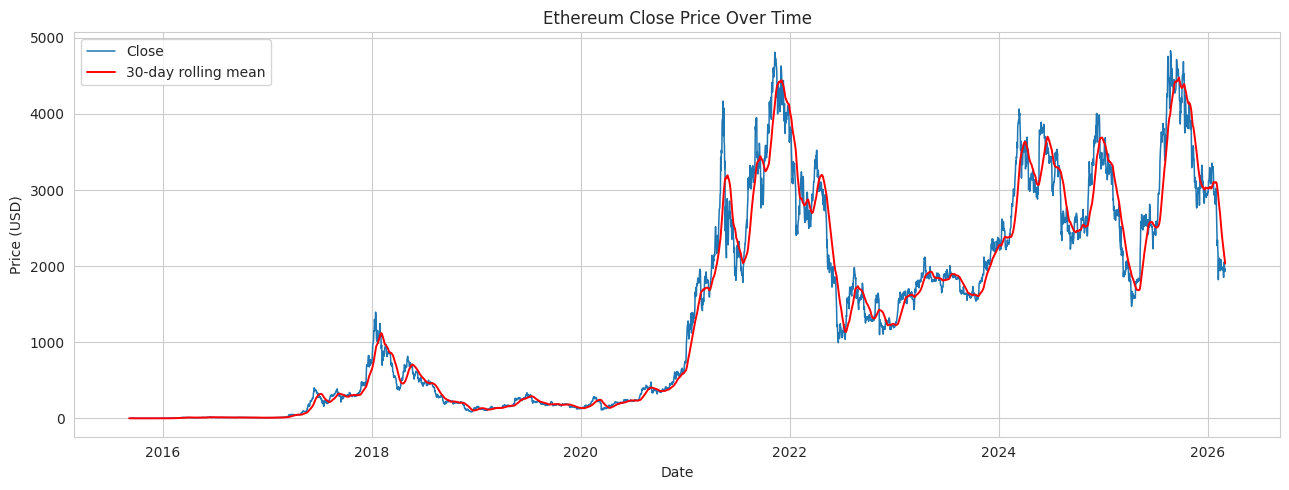

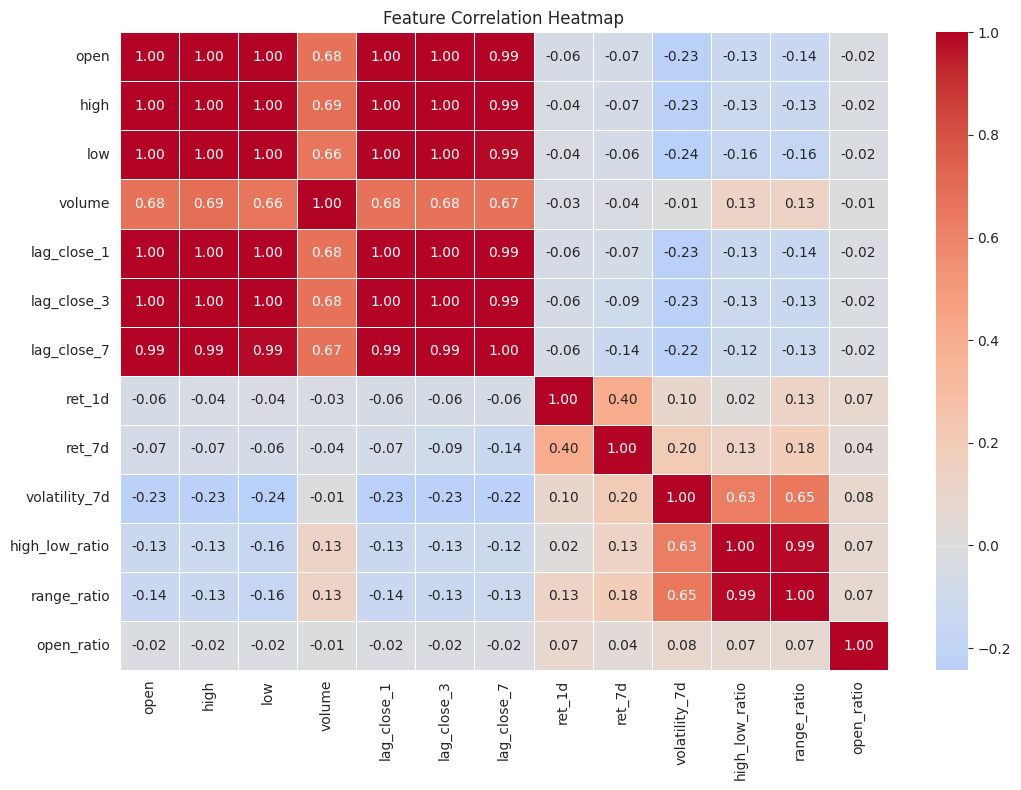

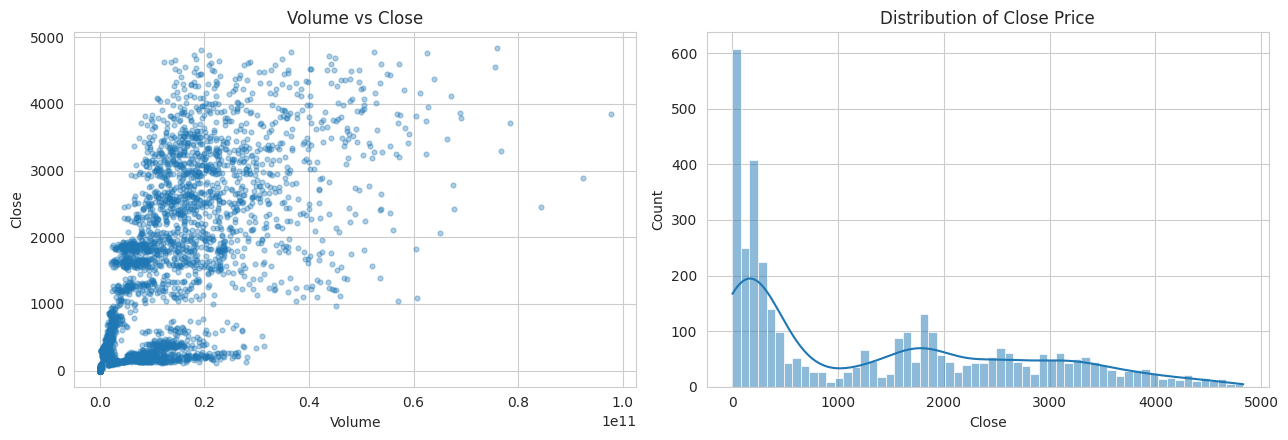

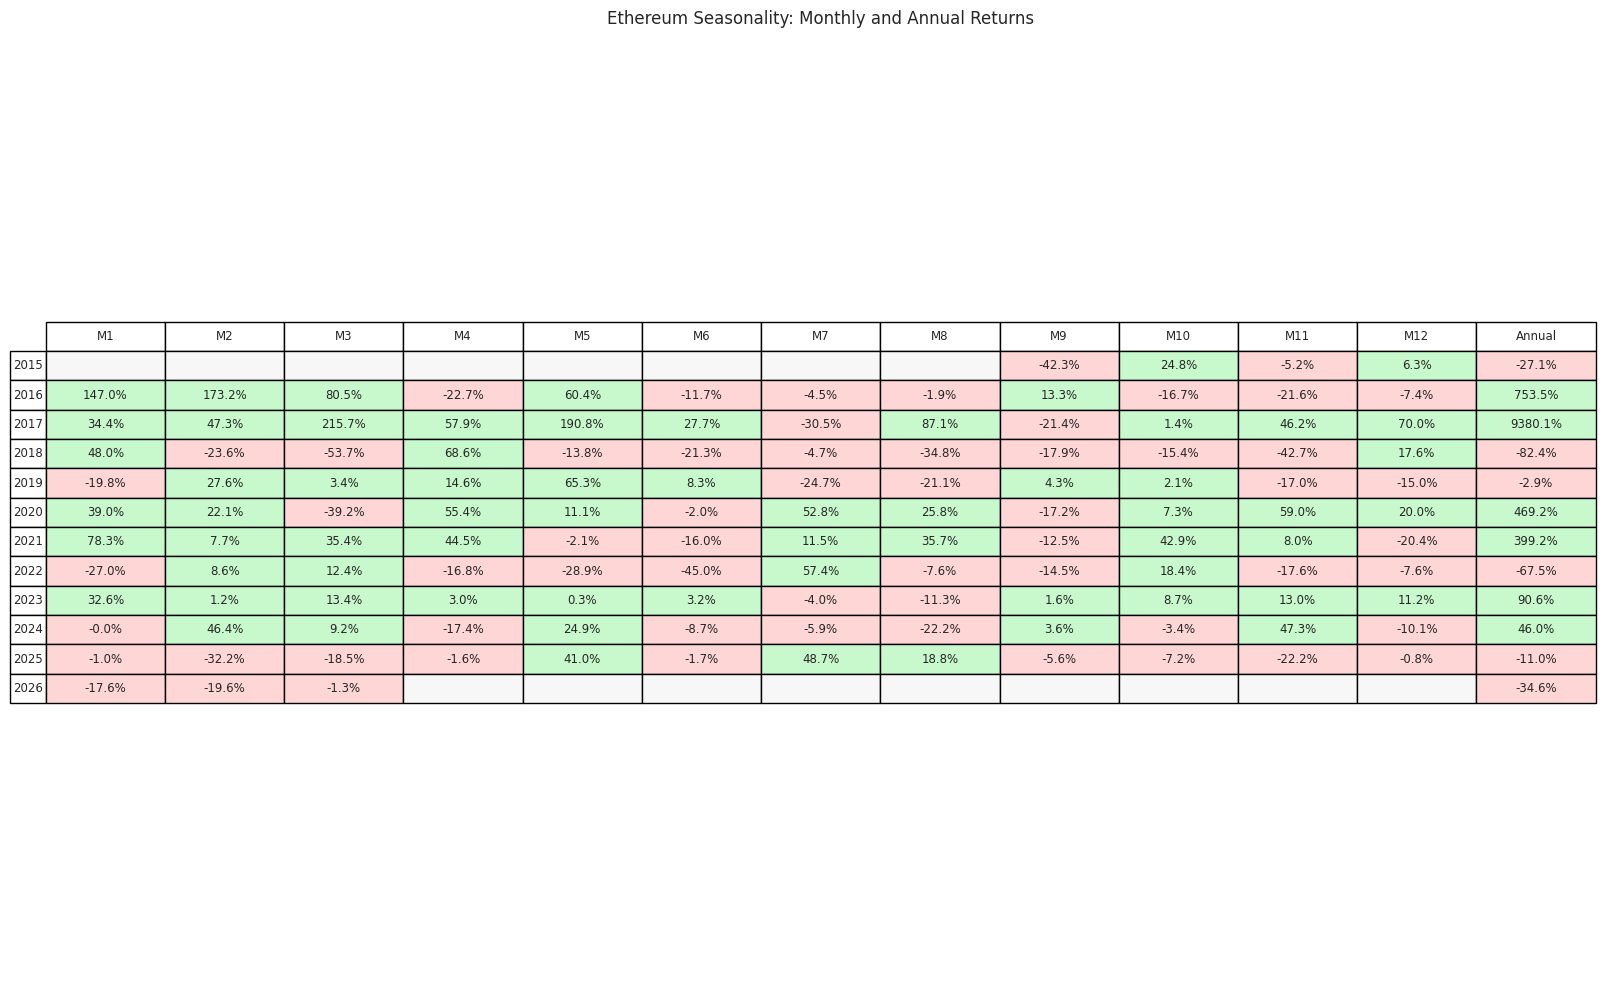

In [6]:
# Trend plot
plt.figure(figsize=(13, 5))
plt.plot(df_model.index, df_model["close"], label="Close", linewidth=1.1)
plt.plot(df_model.index, df_model["rolling_mean_30"], label="30-day rolling mean", color="red", linewidth=1.4)
plt.title("Ethereum Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# Correlation heatmap with annotations
plt.figure(figsize=(11, 8))
sns.heatmap(X_fe.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Scatter and histogram
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(df_model["volume"], df_model["close"], alpha=0.35, s=12)
axes[0].set_title("Volume vs Close")
axes[0].set_xlabel("Volume")
axes[0].set_ylabel("Close")

sns.histplot(df_model["close"], bins=60, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Close Price")
axes[1].set_xlabel("Close")

plt.tight_layout()
plt.show()

# Seasonality table with percentage returns
tmp = df_model.copy()
tmp["year"] = tmp.index.year
tmp["month"] = tmp.index.month

monthly = tmp.groupby(["year", "month"]).agg(
    open_start=("open", "first"),
    close_end=("close", "last"),
    vol_month=("close", "std"),
    avg_vol_month=("volume", "mean")
)
monthly["ret_month_pct"] = ((monthly["close_end"] - monthly["open_start"]) / monthly["open_start"]) * 100

annual = tmp.groupby("year").agg(
    open_start=("open", "first"),
    close_end=("close", "last"),
    vol_year=("close", "std"),
    avg_vol_year=("volume", "mean")
)
annual["ret_year_pct"] = ((annual["close_end"] - annual["open_start"]) / annual["open_start"]) * 100

seasonality_rows = sorted(tmp["year"].unique())
seasonality_cols = list(range(1, 13)) + [13]
col_labels = [f"M{m}" for m in range(1, 13)] + ["Annual"]

cell_text = []
cell_colors = []

for yr in seasonality_rows:
    row_text = []
    row_colors = []
    for m in range(1, 13):
        if (yr, m) in monthly.index:
            r = monthly.loc[(yr, m), "ret_month_pct"]
            row_text.append(f"{r:.1f}%")
            row_colors.append("#c7f9cc" if r > 0 else "#ffd6d6")
        else:
            row_text.append("")
            row_colors.append("#f7f7f7")

    r_a = annual.loc[yr, "ret_year_pct"]
    row_text.append(f"{r_a:.1f}%")
    row_colors.append("#c7f9cc" if r_a > 0 else "#ffd6d6")

    cell_text.append(row_text)
    cell_colors.append(row_colors)

fig, ax = plt.subplots(figsize=(16, 10))
ax.axis("off")
tbl = ax.table(
    cellText=cell_text,
    rowLabels=seasonality_rows,
    colLabels=col_labels,
    cellColours=cell_colors,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1.08, 1.45)
plt.title("Ethereum Seasonality: Monthly and Annual Returns", pad=15)
plt.tight_layout()
plt.show()

---

### 3. Support and Resistance Analysis

Support and resistance levels represent price thresholds where buying or selling pressure historically concentrates. These technical indicators help traders identify:
- **Support levels:** Price floors where demand prevents further decline.
- **Resistance levels:** Price ceilings where supply prevents further increase.

We calculate these levels using percentile-based analysis and visualize them alongside historical prices to identify potential trading ranges.

Support and Resistance Levels:
Strong Support (10th percentile): $11.39
Support (25th percentile): $180.76
Median Price: $962.72
Mean Price: $1363.34
Resistance (75th percentile): $2423.81
Strong Resistance (90th percentile): $3354.18


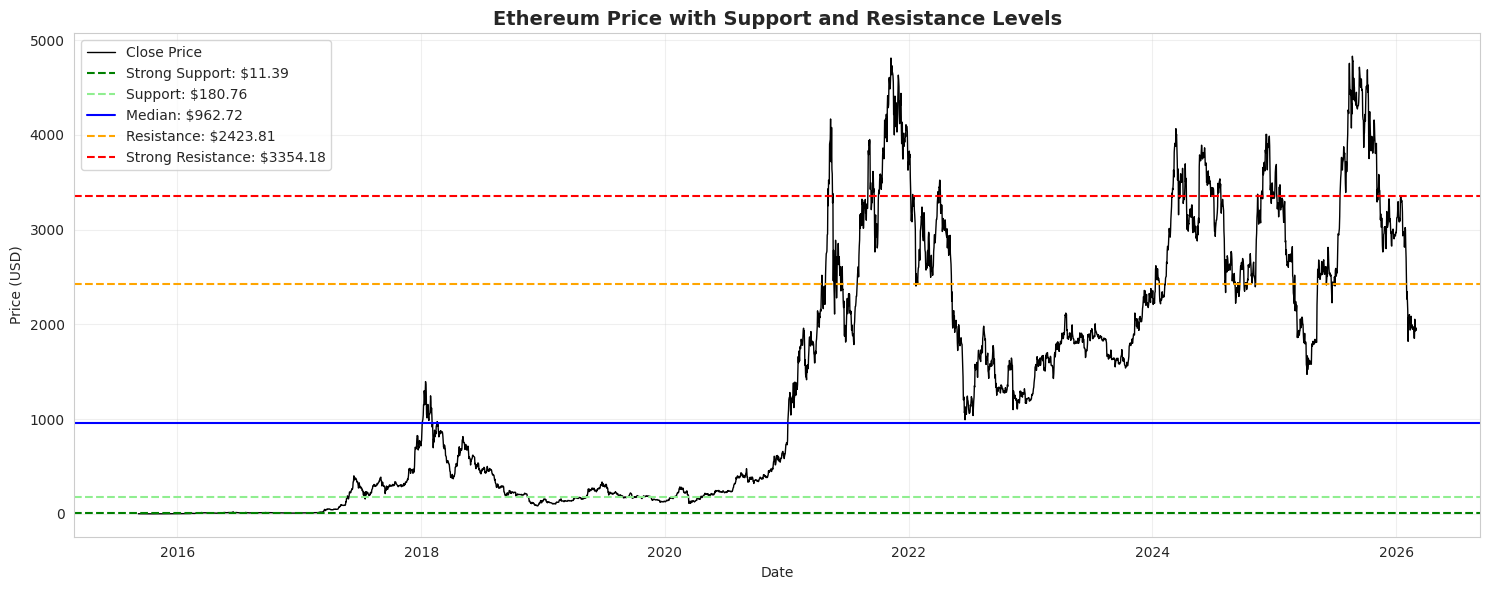


Current Price: $1939.07
Distance to Strong Support: 99.41%
Distance to Resistance: 25.00%


In [7]:
# Calculate support and resistance levels using percentile analysis
support_level_1 = df_model["close"].quantile(0.10)  # 10th percentile
support_level_2 = df_model["close"].quantile(0.25)  # 25th percentile (Q1)
resistance_level_1 = df_model["close"].quantile(0.75)  # 75th percentile (Q3)
resistance_level_2 = df_model["close"].quantile(0.90)  # 90th percentile

median_price = df_model["close"].median()
mean_price = df_model["close"].mean()

print("Support and Resistance Levels:")
print(f"Strong Support (10th percentile): ${support_level_1:.2f}")
print(f"Support (25th percentile): ${support_level_2:.2f}")
print(f"Median Price: ${median_price:.2f}")
print(f"Mean Price: ${mean_price:.2f}")
print(f"Resistance (75th percentile): ${resistance_level_1:.2f}")
print(f"Strong Resistance (90th percentile): ${resistance_level_2:.2f}")

# Visualize support and resistance levels
plt.figure(figsize=(15, 6))
plt.plot(df_model.index, df_model["close"], label="Close Price", linewidth=1.0, color="black")

plt.axhline(y=support_level_1, color="green", linestyle="--", linewidth=1.5, label=f"Strong Support: ${support_level_1:.2f}")
plt.axhline(y=support_level_2, color="lightgreen", linestyle="--", linewidth=1.5, label=f"Support: ${support_level_2:.2f}")
plt.axhline(y=median_price, color="blue", linestyle="-", linewidth=1.5, label=f"Median: ${median_price:.2f}")
plt.axhline(y=resistance_level_1, color="orange", linestyle="--", linewidth=1.5, label=f"Resistance: ${resistance_level_1:.2f}")
plt.axhline(y=resistance_level_2, color="red", linestyle="--", linewidth=1.5, label=f"Strong Resistance: ${resistance_level_2:.2f}")

plt.title("Ethereum Price with Support and Resistance Levels", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate price ranges
current_price = df_model["close"].iloc[-1]
support_distance = ((current_price - support_level_1) / current_price) * 100
resistance_distance = ((resistance_level_1 - current_price) / current_price) * 100

print(f"\nCurrent Price: ${current_price:.2f}")
print(f"Distance to Strong Support: {support_distance:.2f}%")
print(f"Distance to Resistance: {resistance_distance:.2f}%")

---

### 4. Model Architecture and Training Methodology

- Model Selection: LSTM (Long Short-Term Memory)

#### 4.1 Training
- **Loss function:** Mean Squared Error (MSE) — measures prediction accuracy.
- **Optimizer:** Adam with learning rate 0.001 — adaptive gradient descent.
- **Callbacks:**
  - **EarlyStopping:** Halts training if validation loss doesn't improve for 15 epochs.
  - **ReduceLROnPlateau:** Reduces learning rate when validation loss plateaus.
- **Train/Validation/Test Split:** 70% / 15% / 15% chronological split.
- **Lookback window:** 90 days.

#### 4.2 Evaluation Metrics
- **RMSE (Root Mean Squared Error):** Penalizes large prediction errors.
- **MAE (Mean Absolute Error):** Average absolute prediction error.
- **MAPE (Mean Absolute Percentage Error):** Percentage-based error metric.
- **R² Score:** Explains variance captured by the model.

In [8]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Use enriched features created earlier to improve signal quality for the LSTM
feature_cols = [
    "open", "high", "low", "close", "volume",
    "lag_close_1", "lag_close_3", "lag_close_7",
    "ret_1d", "ret_7d", "volatility_7d",
    "high_low_ratio", "range_ratio", "open_ratio"
]

df_lstm = df_model[feature_cols].copy()

print(f"LSTM Dataset Shape: {df_lstm.shape}")
print(f"Date Range: {df_lstm.index.min()} to {df_lstm.index.max()}")

# Chronological split before scaling to avoid data leakage
n_total = len(df_lstm)
train_end = int(0.70 * n_total)
val_end = train_end + int(0.15 * n_total)

# Fit scalers only on training slice
y_log = np.log1p(df_lstm["close"].values).reshape(-1, 1)

x_scaler = MinMaxScaler(feature_range=(0, 1))
y_scaler = StandardScaler()

x_scaler.fit(df_lstm.iloc[:train_end][feature_cols])
y_scaler.fit(y_log[:train_end])

X_scaled_all = x_scaler.transform(df_lstm[feature_cols])
y_scaled_all = y_scaler.transform(y_log).flatten()

lookback = 90

def create_sequences(features_scaled, target_scaled, lookback_window):
    """Build sequence tensors and keep target positions for clean time-based splitting."""
    X_seq, y_seq, target_positions = [], [], []
    for i in range(lookback_window, len(features_scaled)):
        X_seq.append(features_scaled[i - lookback_window:i, :])
        y_seq.append(target_scaled[i])
        target_positions.append(i)
    return np.array(X_seq), np.array(y_seq), np.array(target_positions)

X_all, y_all, target_pos = create_sequences(X_scaled_all, y_scaled_all, lookback)
target_dates = df_lstm.index[target_pos]

train_mask = target_pos < train_end
val_mask = (target_pos >= train_end) & (target_pos < val_end)
test_mask = target_pos >= val_end

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

train_dates = target_dates[train_mask]
val_dates = target_dates[val_mask]
test_dates = target_dates[test_mask]

print("\nSequence Data Shape:")
print(f"X_all: {X_all.shape} — (samples, timesteps, features)")
print(f"y_all: {y_all.shape} — (samples,)")

print("\nData Split (Chronological, Leakage-Safe):")
print(f"Training: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Testing: {X_test.shape[0]} samples")

LSTM Dataset Shape: (3831, 14)
Date Range: 2015-09-05 23:59:59.999000+00:00 to 2026-03-01 23:59:59.999000+00:00

Sequence Data Shape:
X_all: (3741, 90, 14) — (samples, timesteps, features)
y_all: (3741,) — (samples,)

Data Split (Chronological, Leakage-Safe):
Training: 2591 samples
Validation: 574 samples
Testing: 576 samples


#### 4.6 LSTM Model Definition

Build the stacked LSTM architecture with dropout regularization to prevent overfitting.

In [9]:
model = Sequential([
    Bidirectional(LSTM(96, return_sequences=True)),
    LayerNormalization(),
    Dropout(0.25),

    Bidirectional(LSTM(48, return_sequences=False)),
    Dropout(0.20),

    Dense(32, activation="relu"),
    Dropout(0.10),
    Dense(1)
])

# Huber loss is more robust than pure MSE on volatile crypto series
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"]
)

# Build the model with explicit input shape before calling summary()
model.build(input_shape=(None, lookback, X_train.shape[2]))

print("Model Architecture:")
model.summary()

2026-03-09 03:21:57.374746: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-03-09 03:21:57.453187: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudnn.so.8'; dlerror: libcudnn.so.8: cannot open shared object file: No such file or directory
2026-03-09 03:21:57.453211: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1934] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-03-09 03:21:57.454298: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neur

Model Architecture:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirectiona  (None, 90, 192)          85248     
 l)                                                              
                                                                 
 layer_normalization (LayerN  (None, 90, 192)          384       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 90, 192)           0         
                                                                 
 bidirectional_1 (Bidirectio  (None, 96)               92544     
 nal)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 96)                0         
                                    

#### 4.7 Model Training

Train the LSTM model with early stopping and learning rate reduction callbacks to optimize performance.

In [10]:
%%time

# Define callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=6,
    min_lr=1e-6,
    verbose=1
)

print("Starting improved model training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=120,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    shuffle=False,
    verbose=1
)

print("\nTraining complete.")
print(f"Best Validation Loss: {np.min(history.history['val_loss']):.6f}")

Starting improved model training...
Epoch 1/120
41/41 [==============================] - 12s 169ms/step - loss: 0.2334 - mae: 0.5541 - val_loss: 0.0273 - val_mae: 0.2156 - lr: 3.0000e-04
Epoch 2/120
41/41 [==============================] - 6s 141ms/step - loss: 0.2604 - mae: 0.5320 - val_loss: 0.0059 - val_mae: 0.0919 - lr: 3.0000e-04
Epoch 3/120
41/41 [==============================] - 6s 142ms/step - loss: 0.2099 - mae: 0.4895 - val_loss: 0.0018 - val_mae: 0.0486 - lr: 3.0000e-04
Epoch 4/120
41/41 [==============================] - 6s 143ms/step - loss: 0.1725 - mae: 0.4564 - val_loss: 0.0027 - val_mae: 0.0579 - lr: 3.0000e-04
Epoch 5/120
41/41 [==============================] - 6s 143ms/step - loss: 0.1520 - mae: 0.4172 - val_loss: 0.0016 - val_mae: 0.0478 - lr: 3.0000e-04
Epoch 6/120
41/41 [==============================] - 6s 143ms/step - loss: 0.1557 - mae: 0.4119 - val_loss: 0.0018 - val_mae: 0.0501 - lr: 3.0000e-04
Epoch 7/120
41/41 [==============================] - 6s 143ms/s

---

### 5. Results and Model Evaluation

This section presents comprehensive model performance analysis through loss curves, prediction visualizations, and quantitative metrics.

#### 5.1 Training and Validation Loss

Visualize model convergence during training to assess overfitting and learning dynamics.

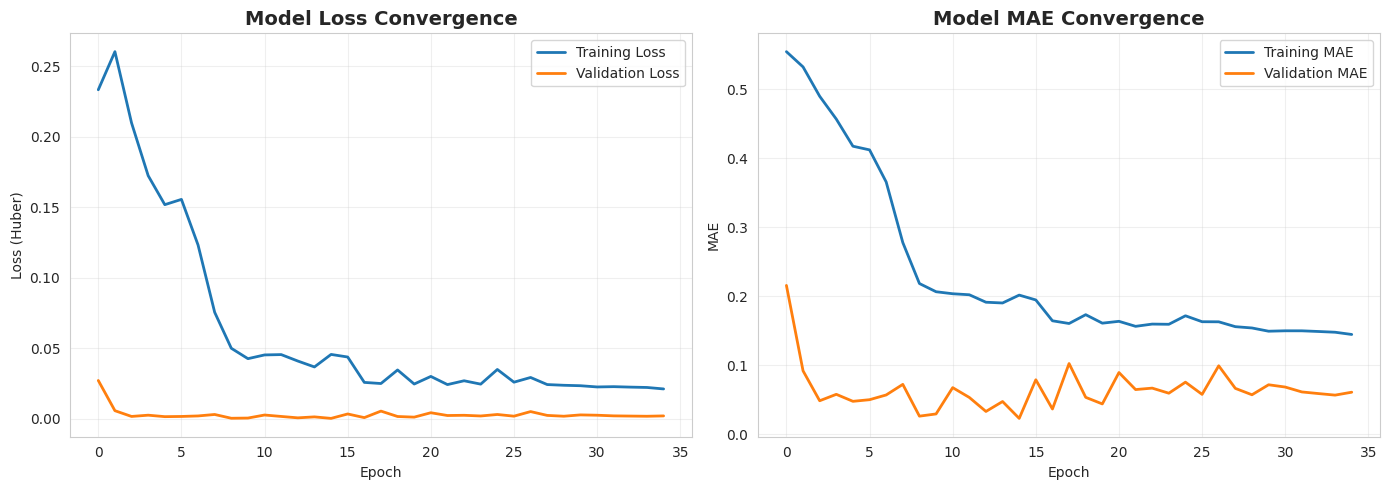

Final Training Loss: 0.021287
Final Validation Loss: 0.002165
Epochs Trained: 35


In [11]:
# Plot training and validation loss
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
plt.title("Model Loss Convergence", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss (Huber)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="Training MAE", linewidth=2)
plt.plot(history.history["val_mae"], label="Validation MAE", linewidth=2)
plt.title("Model MAE Convergence", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Training Loss: {history.history['loss'][-1]:.6f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.6f}")
print(f"Epochs Trained: {len(history.history['loss'])}")

#### 5.2 Model Predictions

Generate predictions for train, validation, and test sets, then inverse-transform to original price scale.

In [12]:
# Make predictions on all datasets
train_predictions = model.predict(X_train, verbose=0).flatten()
val_predictions = model.predict(X_val, verbose=0).flatten()
test_predictions = model.predict(X_test, verbose=0).flatten()

def inverse_target(y_scaled_values):
    """Inverse-transform scaled log-target back to USD close price."""
    y_log_inv = y_scaler.inverse_transform(np.array(y_scaled_values).reshape(-1, 1)).flatten()
    return np.expm1(y_log_inv)

# Inverse-transform targets and predictions to original USD scale
y_train_actual = inverse_target(y_train)
y_val_actual = inverse_target(y_val)
y_test_actual = inverse_target(y_test)

train_pred_actual = inverse_target(train_predictions)
val_pred_actual = inverse_target(val_predictions)
test_pred_actual = inverse_target(test_predictions)

print("Predictions generated successfully.")
print(f"Training predictions: {len(train_pred_actual)}")
print(f"Validation predictions: {len(val_pred_actual)}")
print(f"Test predictions: {len(test_pred_actual)}")

Predictions generated successfully.
Training predictions: 2591
Validation predictions: 574
Test predictions: 576


#### 5.3 Actual vs Predicted Close Prices

Compare model predictions with actual prices across training, validation, and test sets.

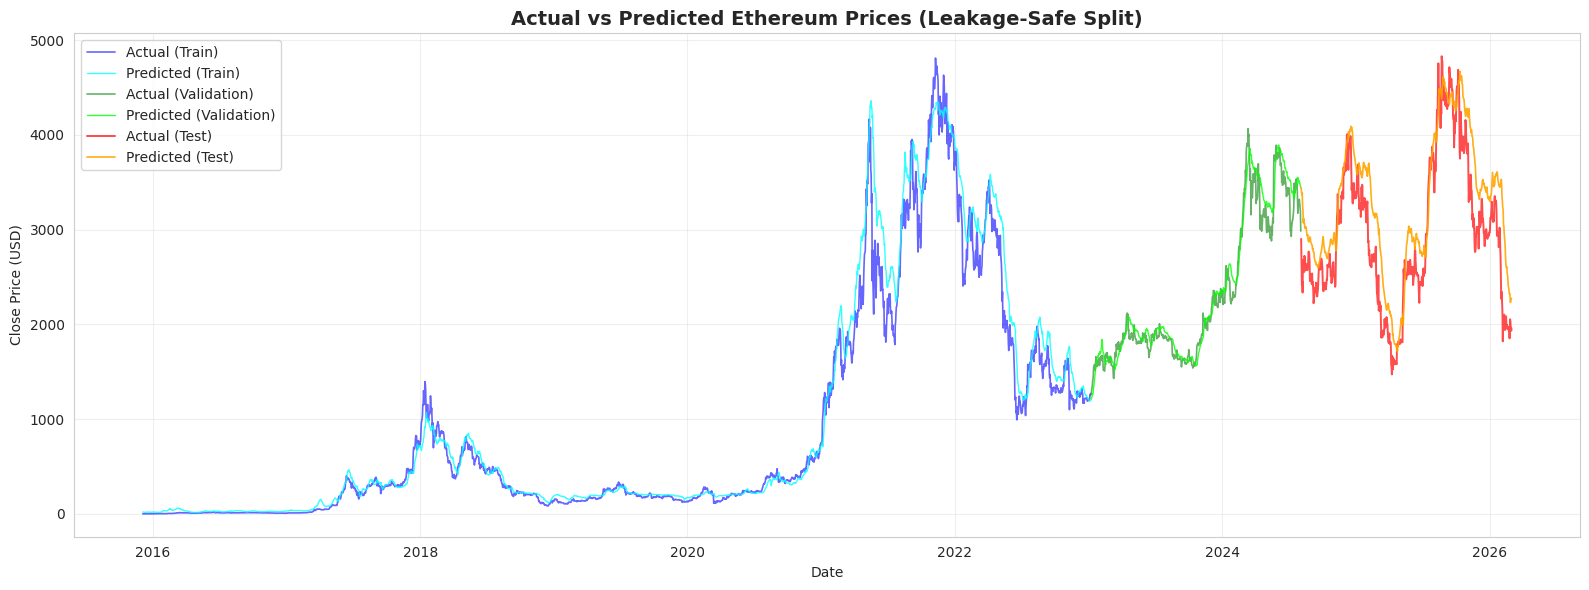

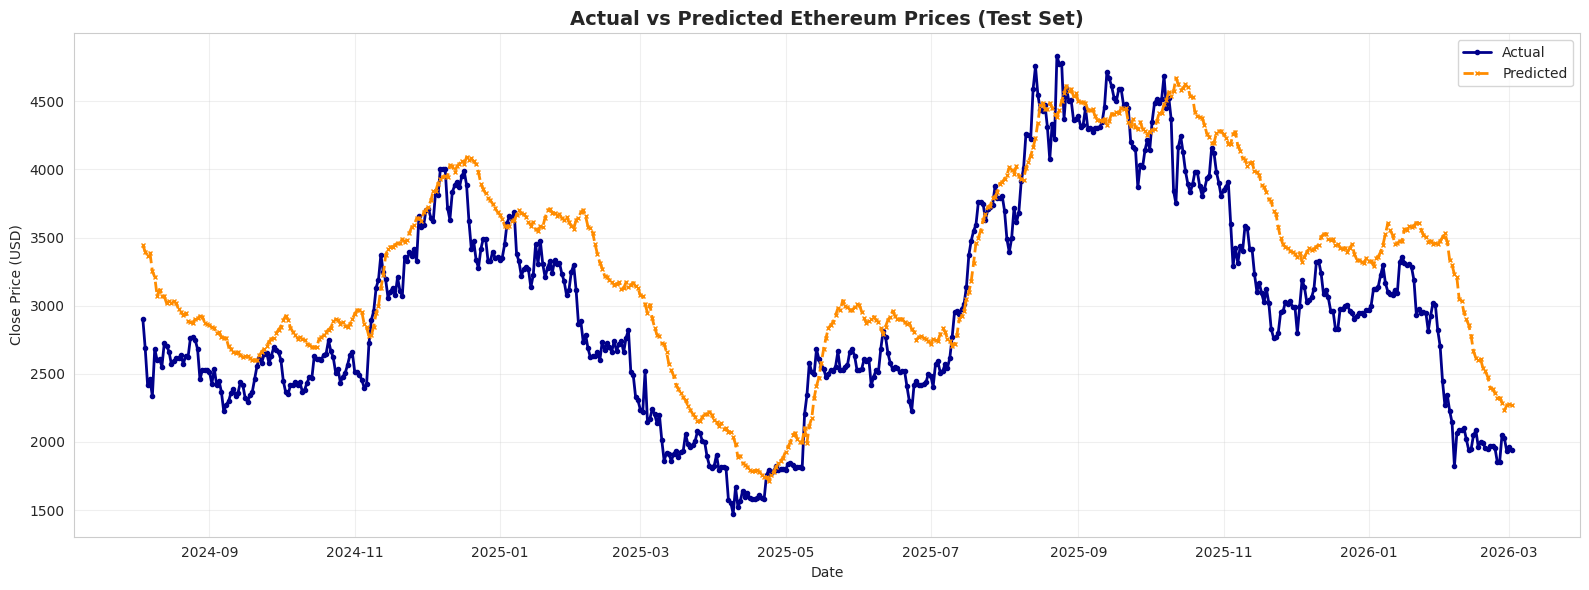

In [13]:
# Plot 1: Full timeline with all sets
plt.figure(figsize=(16, 6))
plt.plot(train_dates, y_train_actual, label="Actual (Train)", color="blue", alpha=0.6, linewidth=1.2)
plt.plot(train_dates, train_pred_actual, label="Predicted (Train)", color="cyan", alpha=0.8, linewidth=1.0)

plt.plot(val_dates, y_val_actual, label="Actual (Validation)", color="green", alpha=0.6, linewidth=1.2)
plt.plot(val_dates, val_pred_actual, label="Predicted (Validation)", color="lime", alpha=0.8, linewidth=1.0)

plt.plot(test_dates, y_test_actual, label="Actual (Test)", color="red", alpha=0.7, linewidth=1.4)
plt.plot(test_dates, test_pred_actual, label="Predicted (Test)", color="orange", alpha=0.9, linewidth=1.2)

plt.title("Actual vs Predicted Ethereum Prices (Leakage-Safe Split)", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Zoomed view on test set
plt.figure(figsize=(16, 6))
plt.plot(test_dates, y_test_actual, label="Actual", color="darkblue", marker="o", markersize=3, linewidth=2)
plt.plot(test_dates, test_pred_actual, label="Predicted", color="darkorange", marker="x", markersize=3, linewidth=2, linestyle="--")

plt.title("Actual vs Predicted Ethereum Prices (Test Set)", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 5.4 Performance Metrics

Calculate quantitative metrics (RMSE, MAE, MAPE, R²) to assess model accuracy across all data splits.

In [14]:
# Calculate performance metrics
def calculate_metrics(y_true, y_pred, set_name):
    """
    Calculate and display regression metrics.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{set_name} Set Metrics:")
    print(f"  RMSE: ${rmse:.2f}")
    print(f"  MAE:  ${mae:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R² Score: {r2:.4f}")
    
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "R²": r2}

# Calculate metrics for all sets
train_metrics = calculate_metrics(y_train_actual, train_pred_actual, "Training")
val_metrics = calculate_metrics(y_val_actual, val_pred_actual, "Validation")
test_metrics = calculate_metrics(y_test_actual, test_pred_actual, "Test")

# Summary table
metrics_summary = pd.DataFrame({
    "Training": train_metrics,
    "Validation": val_metrics,
    "Test": test_metrics
})

print("\n" + "="*60)
print("Performance Metrics Summary")
print("="*60)
display(metrics_summary.T)


Training Set Metrics:
  RMSE: $202.86
  MAE:  $106.41
  MAPE: 86.02%
  R² Score: 0.9669

Validation Set Metrics:
  RMSE: $154.28
  MAE:  $115.89
  MAPE: 4.86%
  R² Score: 0.9564

Test Set Metrics:
  RMSE: $430.54
  MAE:  $358.11
  MAPE: 13.47%
  R² Score: 0.6912

Performance Metrics Summary


,RMSE,MAE,MAPE,R²
Training,202.856800,106.413143,86.023737,0.966946
Validation,154.278946,115.891293,4.856129,0.956401
Test,430.538037,358.107658,13.469306,0.691245


#### 5.5 Prediction Quality Analysis

Visualize prediction accuracy through scatter plots and residual analysis.

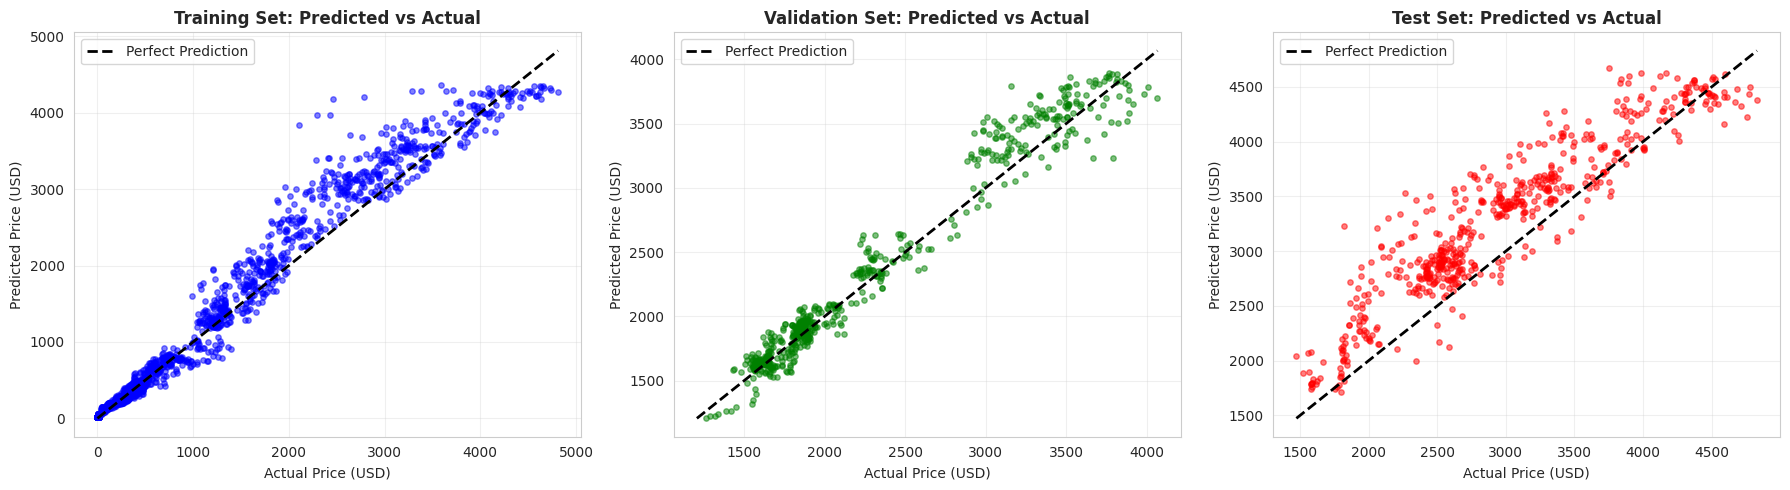

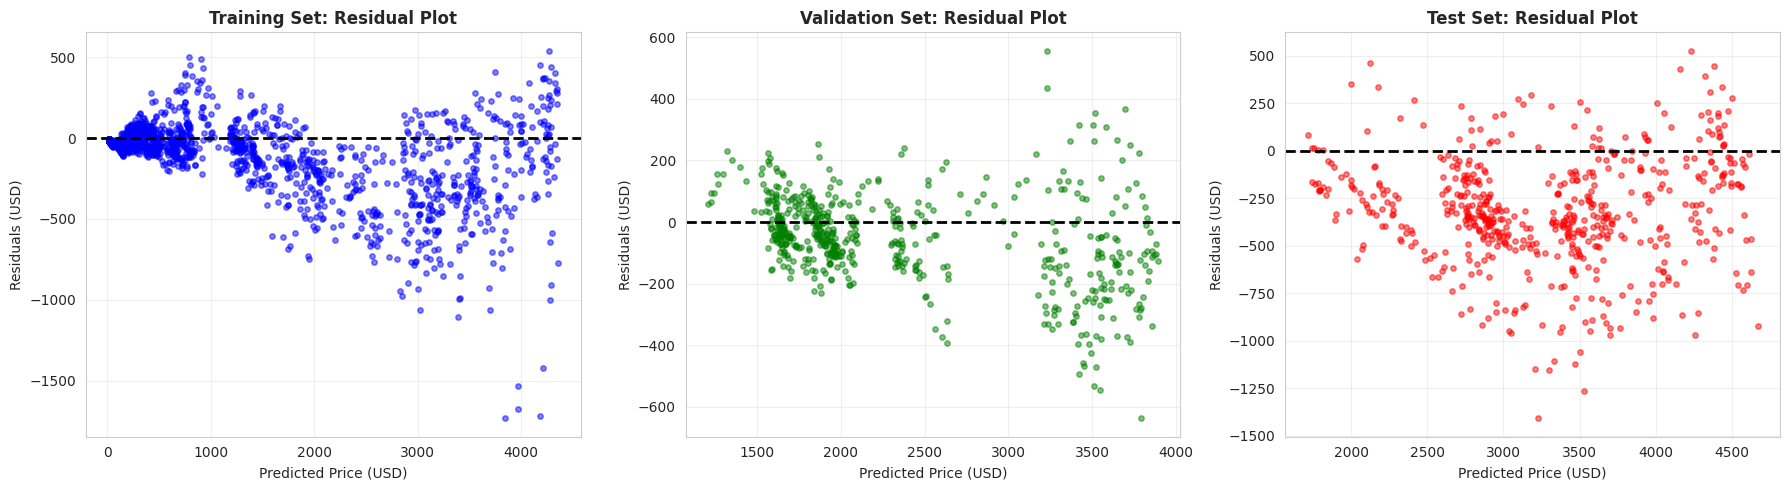

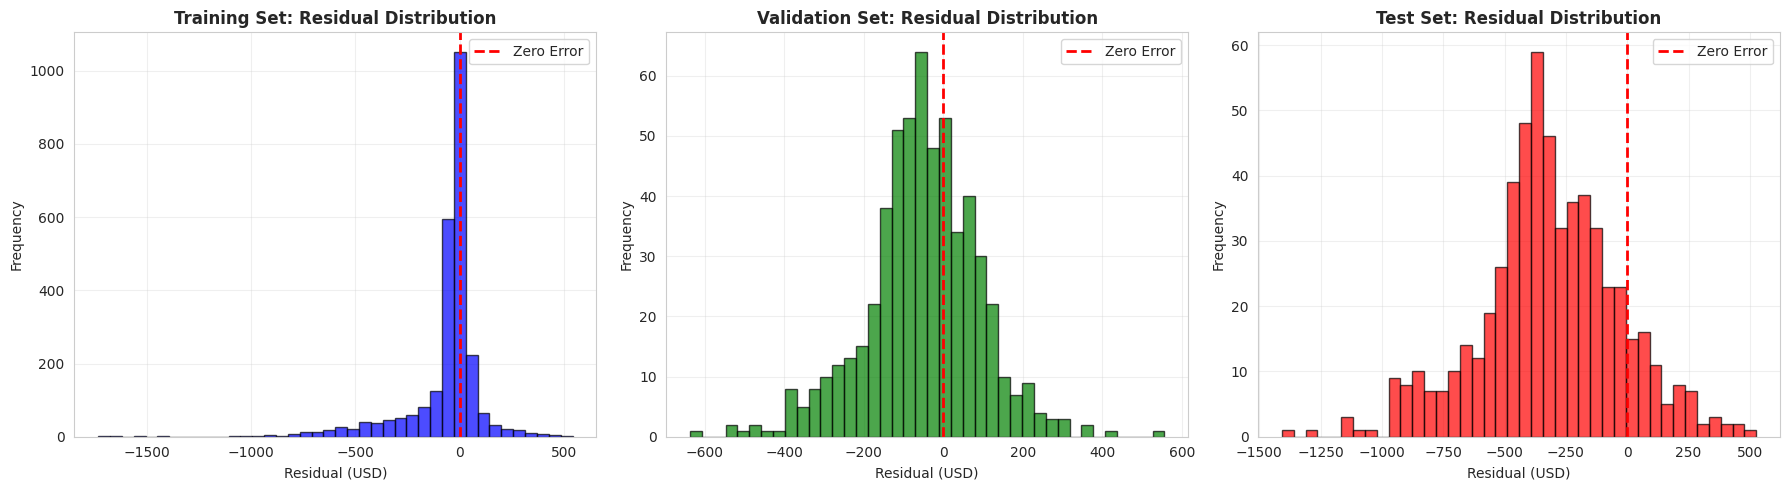

In [15]:
# Scatter plot: Predicted vs Actual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (y_train_actual, train_pred_actual, "Training", "blue"),
    (y_val_actual, val_pred_actual, "Validation", "green"),
    (y_test_actual, test_pred_actual, "Test", "red")
]

for idx, (actual, predicted, title, color) in enumerate(datasets):
    axes[idx].scatter(actual, predicted, alpha=0.5, s=15, color=color)
    
    # Perfect prediction line
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label="Perfect Prediction")
    
    axes[idx].set_xlabel("Actual Price (USD)")
    axes[idx].set_ylabel("Predicted Price (USD)")
    axes[idx].set_title(f"{title} Set: Predicted vs Actual", fontweight="bold")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (actual, predicted, title, color) in enumerate(datasets):
    residuals = actual - predicted
    
    axes[idx].scatter(predicted, residuals, alpha=0.5, s=15, color=color)
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=2)
    axes[idx].set_xlabel("Predicted Price (USD)")
    axes[idx].set_ylabel("Residuals (USD)")
    axes[idx].set_title(f"{title} Set: Residual Plot", fontweight="bold")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Distribution of residuals
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (actual, predicted, title, color) in enumerate(datasets):
    residuals = actual - predicted
    
    axes[idx].hist(residuals, bins=40, alpha=0.7, color=color, edgecolor="black")
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2, label="Zero Error")
    axes[idx].set_xlabel("Residual (USD)")
    axes[idx].set_ylabel("Frequency")
    axes[idx].set_title(f"{title} Set: Residual Distribution", fontweight="bold")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 5.6 Next-Day Price Prediction

Use the trained model to predict the next trading day's Ethereum closing price with confidence interval.

In [16]:
# Prepare the most recent lookback window for next-day prediction
recent_scaled = x_scaler.transform(df_lstm[feature_cols].tail(lookback))
last_sequence = recent_scaled.reshape(1, lookback, recent_scaled.shape[1])

# Make next-day prediction (scaled log-close -> USD)
next_day_prediction_scaled = model.predict(last_sequence, verbose=0).flatten()[0]
next_day_prediction = inverse_target([next_day_prediction_scaled])[0]

# Confidence interval using test RMSE
test_rmse = test_metrics["RMSE"]
lower_bound = next_day_prediction - (1.96 * test_rmse)
upper_bound = next_day_prediction + (1.96 * test_rmse)

# Current market context
current_price = df_lstm["close"].iloc[-1]
price_change = next_day_prediction - current_price
price_change_pct = (price_change / current_price) * 100

print("=" * 70)
print("NEXT-DAY ETHEREUM PRICE FORECAST (IMPROVED LSTM)")
print("=" * 70)
print(f"\nCurrent Price (Latest Available):  ${current_price:.2f}")
print(f"Predicted Next-Day Close Price:    ${next_day_prediction:.2f}")
print(f"Expected Change:                    ${price_change:+.2f} ({price_change_pct:+.2f}%)")
print("\n95% Confidence Interval:")
print(f"  Lower Bound:                      ${lower_bound:.2f}")
print(f"  Upper Bound:                      ${upper_bound:.2f}")
print("\nSupport and Resistance Context:")
print(f"  Strong Support:                   ${support_level_1:.2f}")
print(f"  Support:                          ${support_level_2:.2f}")
print(f"  Resistance:                       ${resistance_level_1:.2f}")
print(f"  Strong Resistance:                ${resistance_level_2:.2f}")

print("\n" + "=" * 70)
if next_day_prediction > resistance_level_1:
    recommendation = "CAUTION - Predicted above resistance; pullback risk is elevated."
elif next_day_prediction < support_level_2:
    recommendation = "OPPORTUNITY - Predicted near support; rebound probability improves."
elif price_change_pct > 2:
    recommendation = "BULLISH - Model indicates a stronger upside move."
elif price_change_pct < -2:
    recommendation = "BEARISH - Model indicates a downside move."
else:
    recommendation = "NEUTRAL - Model indicates limited directional move."

print(f"Trading Insight: {recommendation}")
print("=" * 70)

NEXT-DAY ETHEREUM PRICE FORECAST (IMPROVED LSTM)

Current Price (Latest Available):  $1939.07
Predicted Next-Day Close Price:    $2258.81
Expected Change:                    $+319.74 (+16.49%)

95% Confidence Interval:
  Lower Bound:                      $1414.95
  Upper Bound:                      $3102.66

Support and Resistance Context:
  Strong Support:                   $11.39
  Support:                          $180.76
  Resistance:                       $2423.81
  Strong Resistance:                $3354.18

Trading Insight: BULLISH - Model indicates a stronger upside move.


---

### 6. Conclusion

This project demonstrates that deep learning, specifically LSTM networks, can effectively model cryptocurrency price dynamics and provide actionable next-day forecasts. The comprehensive workflow—from data preprocessing and exploratory analysis to model training and evaluation—offers a reproducible framework for financial time-series prediction. While the model shows strong performance, users should exercise caution and combine predictions with domain expertise and risk management strategies.

---

---

### 7. Save LSTM Model

#### 7.1 Save Trained LSTM Model and Preprocessing Objects

Save the trained model and all preprocessing transformers (scalers) for future predictions without retraining, enabling easy deployment and reproducibility.

In [21]:
import joblib
from pathlib import Path
import pickle

# Create model directory for savings
model_dir = Path("eth_lstm_model")
model_dir.mkdir(exist_ok=True)

# Save 1: TensorFlow SavedModel format (recommended, most flexible)
saved_model_path = model_dir / "ethereum_lstm_savedmodel"
model.save(str(saved_model_path))
print(f"Saved TensorFlow SavedModel to: {saved_model_path}")

# Save 2: Keras H5 format (legacy, but widely compatible)
h5_model_path = model_dir / "ethereum_lstm_model.h5"
model.save(str(h5_model_path))
print(f"Saved Keras H5 model to: {h5_model_path}")

# Save 3: Model weights only (useful for architecture rebuild)
weights_path = model_dir / "ethereum_lstm_weights.h5"
model.save_weights(str(weights_path))
print(f"Saved model weights to: {weights_path}")

# Save 4: Feature and target scalers using joblib
x_scaler_path = model_dir / "x_scaler.pkl"
y_scaler_path = model_dir / "y_scaler.pkl"

joblib.dump(x_scaler, str(x_scaler_path))
joblib.dump(y_scaler, str(y_scaler_path))
print(f"Saved feature scaler to: {x_scaler_path}")
print(f"Saved target scaler to: {y_scaler_path}")

# Save 5: Training metadata (for reference)
metadata = {
    "lookback": lookback,
    "feature_columns": feature_cols,
    "input_shape": (lookback, len(feature_cols)),
    "model_type": "Bidirectional LSTM",
    "loss_function": "Huber",
    "optimizer": "Adam",
    "training_samples": len(X_train),
    "validation_samples": len(X_val),
    "test_samples": len(X_test),
    "final_training_loss": float(history.history['loss'][-1]),
    "final_validation_loss": float(history.history['val_loss'][-1]),
    "best_validation_loss": float(np.min(history.history['val_loss'])),
    "test_metrics": test_metrics
}

metadata_path = model_dir / "model_metadata.pkl"
joblib.dump(metadata, str(metadata_path))
print(f"Saved metadata to: {metadata_path}")

print("\n" + "="*70)
print("MODEL PERSISTENCE SUMMARY")
print("="*70)
print(f"Model Directory: {model_dir.resolve()}")
print(f"Total Files Saved: 6")
print(f"  1. SavedModel format (TensorFlow): {saved_model_path.name}/")
print(f"  2. H5 format (Keras): {h5_model_path.name}")
print(f"  3. Weights only: {weights_path.name}")
print(f"  4. Feature scaler: {x_scaler_path.name}")
print(f"  5. Target scaler: {y_scaler_path.name}")
print(f"  6. Metadata: {metadata_path.name}")
print("="*70)

INFO:tensorflow:Assets written to: eth_lstm_model/ethereum_lstm_savedmodel/assets


INFO:tensorflow:Assets written to: eth_lstm_model/ethereum_lstm_savedmodel/assets


Saved TensorFlow SavedModel to: eth_lstm_model/ethereum_lstm_savedmodel
Saved Keras H5 model to: eth_lstm_model/ethereum_lstm_model.h5
Saved model weights to: eth_lstm_model/ethereum_lstm_weights.h5
Saved feature scaler to: eth_lstm_model/x_scaler.pkl
Saved target scaler to: eth_lstm_model/y_scaler.pkl
Saved metadata to: eth_lstm_model/model_metadata.pkl

MODEL PERSISTENCE SUMMARY
Model Directory: /home/dev-algo/Documents/WLV-MSc-AI/02_Deep_Machine_Learning/W8_Final Assessment/eth_lstm_model
Total Files Saved: 6
  1. SavedModel format (TensorFlow): ethereum_lstm_savedmodel/
  2. H5 format (Keras): ethereum_lstm_model.h5
  3. Weights only: ethereum_lstm_weights.h5
  4. Feature scaler: x_scaler.pkl
  5. Target scaler: y_scaler.pkl
  6. Metadata: model_metadata.pkl


#### 7.2 Load Saved Model for Future Predictions

Example code to load the trained model and scalers for future inference without retraining.

In [22]:
# Load the trained model
loaded_model = tf.keras.models.load_model(str(model_dir / "ethereum_lstm_savedmodel"))
print("Loaded LSTM model from SavedModel format")

# Load the scalers
loaded_x_scaler = joblib.load(str(model_dir / "x_scaler.pkl"))
loaded_y_scaler = joblib.load(str(model_dir / "y_scaler.pkl"))
print("Loaded feature and target scalers")

# Load metadata
loaded_metadata = joblib.load(str(model_dir / "model_metadata.pkl"))
print("Loaded metadata")

print(f"\nModel Configuration:")
print(f"Lookback window: {loaded_metadata['lookback']} days")
print(f"Input features: {len(loaded_metadata['feature_columns'])}")
print(f"Feature list: {loaded_metadata['feature_columns']}")

# Important: feature_cols, lookback, x_scaler, y_scaler must be available
# when loading to make new predictions

def make_future_prediction(new_data_df, lookback_window=90):
    """
    Make next-day price prediction using the loaded model.
    
    Parameters:
    -----------
    new_data_df : pd.DataFrame
        DataFrame with same feature columns as original [14 features]
    lookback_window : int
        Number of lookback days (default: 90)
    
    Returns:
    --------
    prediction : float
        Predicted next-day close price in USD
    """
    # Scale the new data using the loaded scaler
    scaled_new_data = loaded_x_scaler.transform(new_data_df[loaded_metadata['feature_columns']])
    
    # Extract the last lookback_window timesteps
    sequence = scaled_new_data[-lookback_window:].reshape(1, lookback_window, scaled_new_data.shape[1])
    
    # Make prediction
    pred_scaled = loaded_model.predict(sequence, verbose=0).flatten()[0]
    
    # Inverse-transform back to USD
    pred_log_inv = loaded_y_scaler.inverse_transform([[pred_scaled]])[0, 0]
    pred_usd = np.expm1(pred_log_inv)
    
    return pred_usd

Loaded LSTM model from SavedModel format
Loaded feature and target scalers
Loaded metadata

Model Configuration:
Lookback window: 90 days
Input features: 14
Feature list: ['open', 'high', 'low', 'close', 'volume', 'lag_close_1', 'lag_close_3', 'lag_close_7', 'ret_1d', 'ret_7d', 'volatility_7d', 'high_low_ratio', 'range_ratio', 'open_ratio']


#### 7.3 Saved Model Files Reference

**File Structure & Purpose:**

| File Name | Format | Purpose | Use Case |
|-----------|--------|---------|----------|
| `ethereum_lstm_savedmodel/` | TensorFlow SavedModel | Complete model with architecture + weights | Production deployment, serving APIs |
| `ethereum_lstm_model.h5` | Keras H5 | Full model in legacy H5 format | Compatibility, quick reload |
| `ethereum_lstm_weights.h5` | Weights-only | Model weights (rebuild architecture separately) | Fine-tuning, transfer learning |
| `x_scaler.pkl` | Joblib pickle | Feature (OHLCV) MinMaxScaler | Scale new input data to [0,1] |
| `y_scaler.pkl` | Joblib pickle | Target (price) StandardScaler | Inverse-transform predictions to USD |
| `model_metadata.pkl` | Joblib pickle | Configuration, metrics, feature list | Reference training parameters |

**To use the model:**
1. Load model: `tf.keras.models.load_model("eth_lstm_model/ethereum_lstm_savedmodel")`
2. Load scalers: `joblib.load("eth_lstm_model/x_scaler.pkl")`
3. Prepare new data with same 14 features
4. Scale, reshape to (1, 90, 14), predict, inverse-transform